# LIBRARY

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# PREPROCESSING

In [2]:
# Load data kotor
df = pd.read_csv('Raw-data/Sintesis_Progressive.csv')

print("Jumlah baris awal:", df.shape[0])
df.head(5)

Jumlah baris awal: 38300


,id_tabungan,counter_tabungan,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,status,keterangan
0,TAB - 0001,1,12-Jun-21,Dana Darurat,9720000.0,1134942,1134942,8585058,belum selesai,NaN
1,TAB-0001,2,2021-06-26,NaN,9720000.0,948640,2083582,7636418,Belum Selesai,Cash
2,TAB-0001,3,2021-07-15,Dana Darurat,9720000.0,1056415,3139997,6580003,Belum Selesai,Cash
3,TAB-0001,4,2021-07-22,DANA DARURAT,9720000.0,1036500,4176497,5543503,BELUM SELESAI,Cash
4,TAB-0001,5,2021-08-08,dana darurat,9720000.0,Rp. 958.707,5135204,4584796,Belum Selesai,Cash


C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\1131176244.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.values, y=missing_data.index, palette="Reds_r")
C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\1131176244.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=['Murni Angka', 'Tercemar Teks/Simbol'], y=[murni_angka, mengandung_teks], palette="viridis")
C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\1131176244.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stat

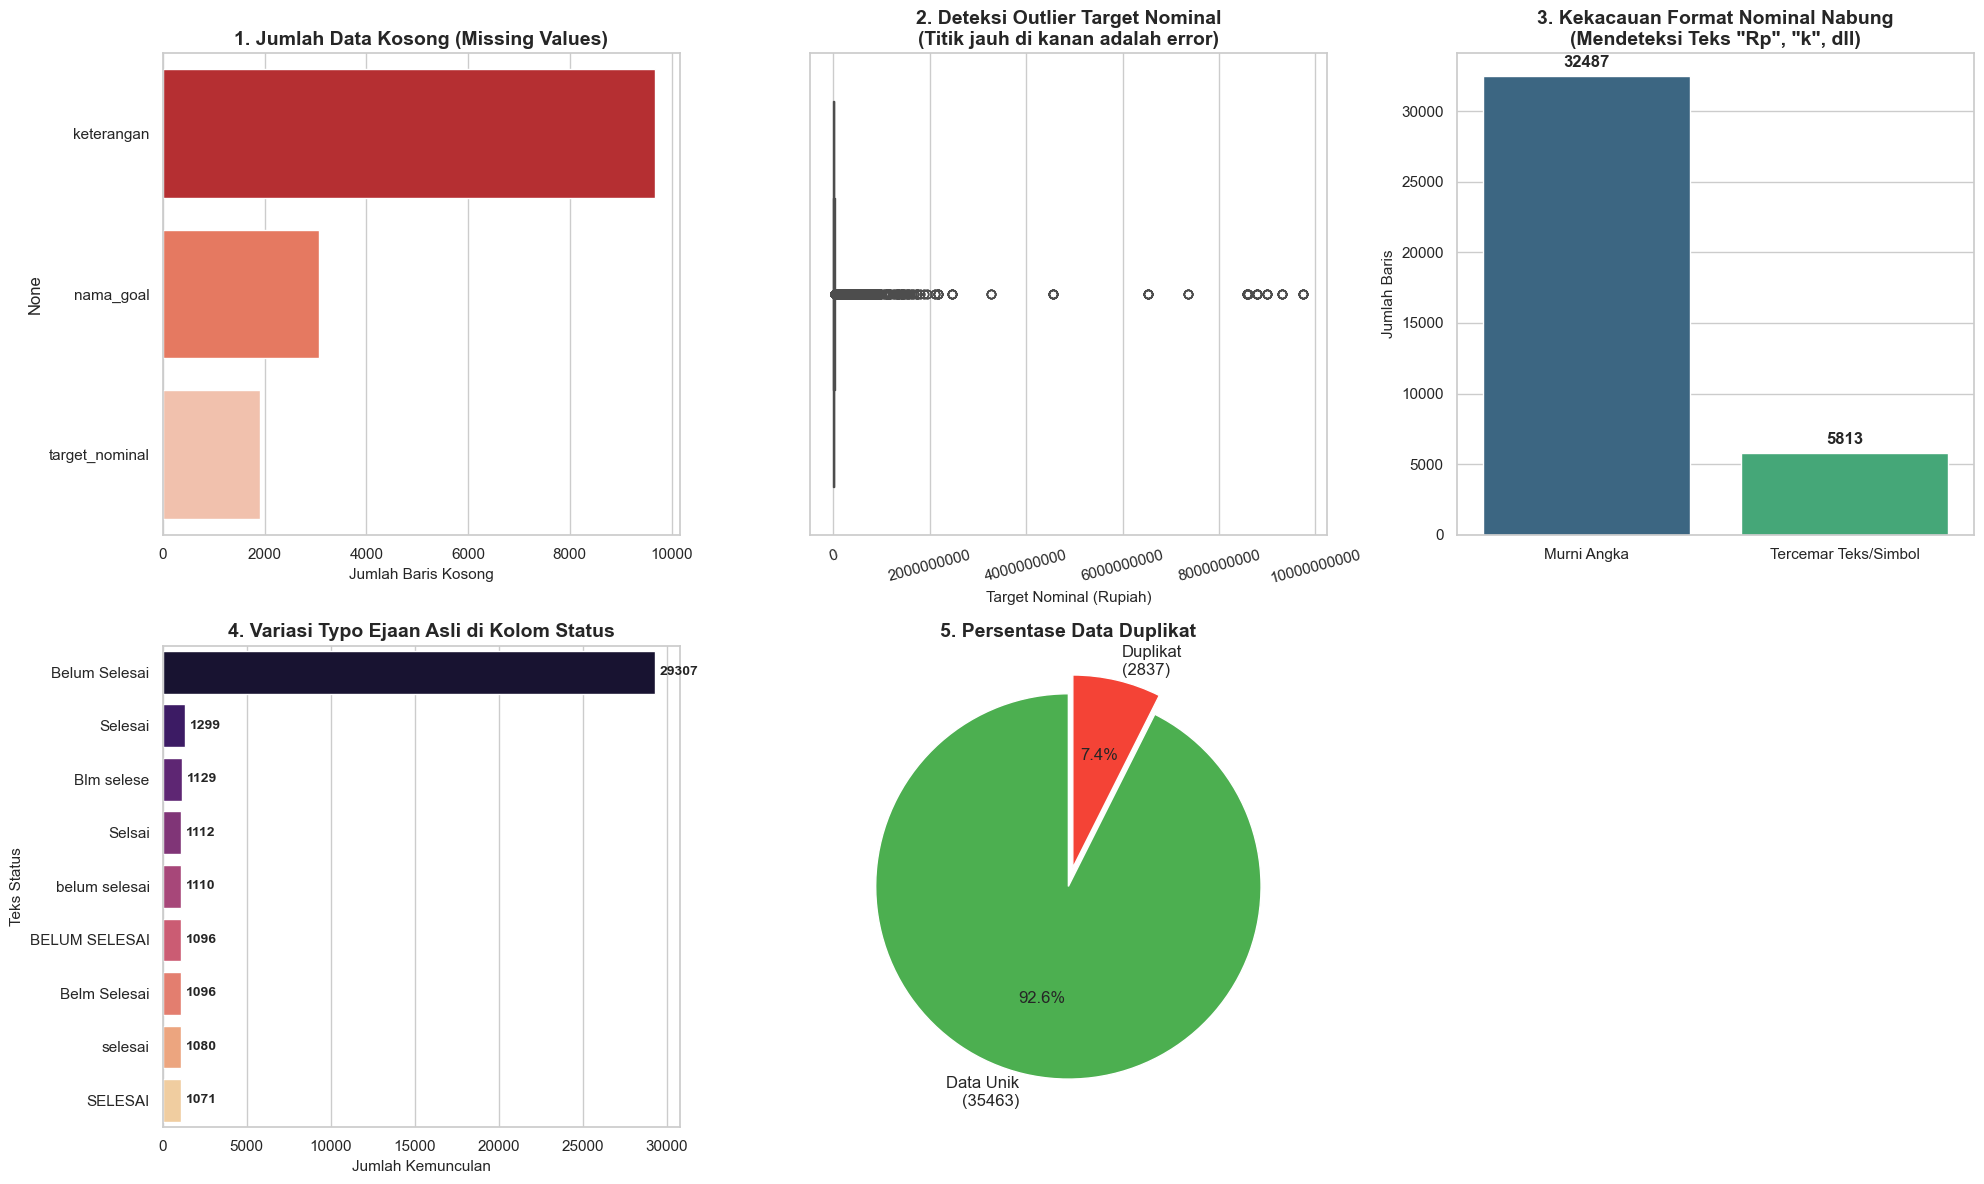

In [3]:
## Visualisasi untuk Deteksi Masalah Data
sns.set_theme(style="whitegrid")
# Perbesar ukuran canvas agar muat 5 grafik
plt.figure(figsize=(20, 12)) 

# GRAFIK 1: Jumlah Missing Values (Data Kosong)
plt.subplot(2, 3, 1) # (2 baris, 3 kolom, posisi 1)
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    sns.barplot(x=missing_data.values, y=missing_data.index, palette="Reds_r")
    plt.title('1. Jumlah Data Kosong (Missing Values)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Baris Kosong', fontsize=11)
else:
    plt.text(0.5, 0.5, 'Tidak ada missing values!', ha='center', va='center', fontsize=14)

# GRAFIK 2: Deteksi Outlier (Target Nominal)
plt.subplot(2, 3, 2)
sns.boxplot(x=df['target_nominal'].dropna(), color='orange')
plt.title('2. Deteksi Outlier Target Nominal\n(Titik jauh di kanan adalah error)', fontsize=14, fontweight='bold')
plt.xlabel('Target Nominal (Rupiah)', fontsize=11)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=15)

# GRAFIK 3: Kekacauan Format Nominal Nabung
plt.subplot(2, 3, 3)
nominal_dropna = df['nominal_nabung'].dropna().astype(str)
murni_angka = nominal_dropna.str.isnumeric().sum()
mengandung_teks = len(nominal_dropna) - murni_angka

bars = sns.barplot(x=['Murni Angka', 'Tercemar Teks/Simbol'], y=[murni_angka, mengandung_teks], palette="viridis")
plt.title('3. Kekacauan Format Nominal Nabung\n(Mendeteksi Teks "Rp", "k", dll)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Baris', fontsize=11)

for i, v in enumerate([murni_angka, mengandung_teks]):
    bars.text(i, v + (max(murni_angka, mengandung_teks)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')

# GRAFIK 4: Kekacauan Teks / Typo di Kolom Status
plt.subplot(2, 3, 4)

status_counts = df['status'].value_counts()

sns.barplot(x=status_counts.values, y=status_counts.index, palette="magma")
plt.title('4. Variasi Typo Ejaan Asli di Kolom Status', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kemunculan', fontsize=11)
plt.ylabel('Teks Status', fontsize=11)

# Tambahkan label angka di sebelah kanan setiap batang
for i, v in enumerate(status_counts.values):
    plt.text(v + (max(status_counts.values)*0.01), i, str(v), va='center', fontsize=10, fontweight='bold')

# GRAFIK 5: Proporsi Duplikasi Data
plt.subplot(2, 3, 5)
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
unique_rows = total_rows - duplicate_rows

plt.pie([unique_rows, duplicate_rows], 
        labels=[f'Data Unik\n({unique_rows})', f'Duplikat\n({duplicate_rows})'], 
        autopct='%1.1f%%', 
        colors=['#4CAF50', '#F44336'], 
        startangle=90, 
        explode=[0, 0.1], 
        textprops={'fontsize': 12})
plt.title('5. Persentase Data Duplikat', fontsize=14, fontweight='bold')

# Tampilkan semua grafik sekaligus dengan rapi
plt.tight_layout()
plt.show()

In [4]:
# mengecek info dataset
print("=== 1. CEK INFO DASAR ===")
df.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df.duplicated().sum())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38300 entries, 0 to 38299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_tabungan       38300 non-null  object 
 1   counter_tabungan  38300 non-null  int64  
 2   tanggal_nabung    38300 non-null  object 
 3   nama_goal         35229 non-null  object 
 4   target_nominal    36389 non-null  float64
 5   nominal_nabung    38300 non-null  object 
 6   total_terkumpul   38300 non-null  int64  
 7   sisa_target       38300 non-null  int64  
 8   status            38300 non-null  object 
 9   keterangan        28624 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 2.9+ MB

=== 2. CEK DATA KOSONG (Missing Values) ===
id_tabungan            0
counter_tabungan       0
tanggal_nabung         0
nama_goal           3071
target_nominal      1911
nominal_nabung         0
total_terkumpul        0
sisa_target        

In [5]:
# Hapus baris duplikat
df = df.drop_duplicates()

# Hapus kolom noise (jika ada)
kolom_dibuang = ['keterangan']
df = df.drop(columns=[col for col in kolom_dibuang if col in df.columns])

print("Jumlah baris setelah hapus duplikat:", len(df))

Jumlah baris setelah hapus duplikat: 35463


In [6]:
## Standarisasi Format
# Bersihkan Format ID
df['id_tabungan'] = df['id_tabungan'].astype(str).str.replace(' ', '', regex=False)
df['id_tabungan'] = df['id_tabungan'].str.replace('(?i)tb_', 'TAB-', regex=True)
df['id_tabungan'] = df['id_tabungan'].str.upper()

# Lihat 5 ID unik pertama
print(df['id_tabungan'].unique()[:10])

['TAB-0001' 'TAB-0002' 'TAB-0003' 'TAB-0004' 'TAB-0005' 'TAB-0006'
 'TAB-0007' 'TAB-0008' 'TAB-0009' 'TAB-0010']


In [7]:
# Rapikan teks Nama Goal
df['nama_goal'] = df['nama_goal'].str.strip().str.title()

# ffill() mengisi dari baris atas ke bawah, bfill() mengisi dari bawah ke atas
df['nama_goal'] = df.groupby('id_tabungan')['nama_goal'].transform(lambda x: x.ffill().bfill())

# Jika  ada 1 ID yang SEMUA barisnya terhapusi, maka akan tetap kosong.maka akan di isi dengan "Tabungan Rusak" sebagai default.
df = df.dropna(subset=['nama_goal'])



# merapikan Typo di Status
def clean_status(val):
    if pd.isna(val): return 'Belum Selesai'
    val = str(val).lower().strip()
    if any(x in val for x in ['belum', 'blm', 'belm']): return 'Belum Selesai'
    if any(x in val for x in ['selesai', 'selsai', 'selese']): return 'Selesai'
    return 'Belum Selesai'

df['status'] = df['status'].apply(clean_status)

print("Nama Goal berhasil dipulihkan berdasar ID, dan Typo Status diperbaiki!")
# Cek apakah ada yang masih kosong di nama_goal setelah proses pemulihan
print("\nSisa data Tabungan Rusak (kalau 0 berarti pulih semua):")
print("\nSisa data kosong di kolom nama_goal:", df['nama_goal'].isna().sum())

C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\1702165746.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['nama_goal'] = df.groupby('id_tabungan')['nama_goal'].transform(lambda x: x.ffill().bfill())


Nama Goal berhasil dipulihkan berdasar ID, dan Typo Status diperbaiki!

Sisa data Tabungan Rusak (kalau 0 berarti pulih semua):

Sisa data kosong di kolom nama_goal: 0


In [8]:
# Ekstraksi Angka dari Kolom Nominal Nabung
def clean_nominal(val):
    if pd.isna(val): return np.nan
    val = str(val).lower().strip()
    
    val = val.replace('rp.', '').replace('rupiah', '').replace('rp', '')
    val = val.replace('.', '').replace(',', '')
    
    if 'k' in val:
        val = val.replace('k', '')
        try: return int(float(val) * 1000)
        except: return np.nan
        
    try: return int(val)
    except: return np.nan

df['nominal_nabung'] = df['nominal_nabung'].apply(clean_nominal)

# Cek apakah sudah jadi angka (float)
print(df['nominal_nabung'].head())

0    1134942
1     948640
2    1056415
3    1036500
4     958707
Name: nominal_nabung, dtype: int64


In [9]:
## Merapikan Tanggal
# Ubah teks tanggal jadi format datetime pandas (Teks aneh akan otomatis jadi NaT)
df['tanggal_nabung'] = pd.to_datetime(df['tanggal_nabung'], errors='coerce')

# Buang baris yang tanggalnya NaT (Not a Time)
df = df.dropna(subset=['tanggal_nabung'])

# Format kembali jadi string standar
df['tanggal_nabung'] = df['tanggal_nabung'].dt.strftime('%Y-%m-%d')

print("Sisa baris setelah pembersihan tanggal:", len(df))

Sisa baris setelah pembersihan tanggal: 33730


C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\1988910318.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tanggal_nabung'] = pd.to_datetime(df['tanggal_nabung'], errors='coerce')


In [10]:
## Menangani Outlier & Missing Value
# Hitung median target per ID
median_targets = df.groupby('id_tabungan')['target_nominal'].transform('median')

# Isi NaN dengan median
df['target_nominal'] = df['target_nominal'].fillna(median_targets)

# Kempeskan nilai outlier (yang tadinya dikali 100)
kondisi_outlier = df['target_nominal'] > (median_targets * 10)
df.loc[kondisi_outlier, 'target_nominal'] = median_targets[kondisi_outlier]

# Cek statistik target nominal yang sudah rapi
print(df['target_nominal'].describe())

count    3.372900e+04
mean     1.779932e+07
std      3.054965e+07
min      1.000000e+05
25%      2.770000e+06
50%      7.120000e+06
75%      1.402000e+07
max      1.729000e+09
Name: target_nominal, dtype: float64


In [11]:
## Sorting Data
df = df.sort_values(by=['id_tabungan', 'counter_tabungan']).reset_index(drop=True)

## Feature Engineering
# Menghitung Jarak Hari Antar Setoran
df['tanggal_nabung'] = pd.to_datetime(df['tanggal_nabung'])
df['jarak_hari_nabung'] = df.groupby('id_tabungan')['tanggal_nabung'].diff().dt.days
df['jarak_hari_nabung'] = df['jarak_hari_nabung'].fillna(0).astype(int)

# Menghitung Persentase Terkumpul
# Rumus: (Total Terkumpul / Target Nominal) * 100
df['persentase_terkumpul'] = (df['total_terkumpul'] / df['target_nominal']) * 100

# Bulatkan persentase ke 2 angka di belakang koma (contoh: 45.67)
df['persentase_terkumpul'] = df['persentase_terkumpul'].round(2)

In [12]:
## Mengubah Format Tanggal Kembali ke Datetime (untuk keperluan analisis selanjutnya)
df['tanggal_nabung'] = pd.to_datetime(df['tanggal_nabung'])

In [13]:
# mengecek info dataset
print("=== 1. CEK INFO DASAR ===")
df.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df.duplicated().sum())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33730 entries, 0 to 33729
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_tabungan           33730 non-null  object        
 1   counter_tabungan      33730 non-null  int64         
 2   tanggal_nabung        33730 non-null  datetime64[ns]
 3   nama_goal             33730 non-null  object        
 4   target_nominal        33729 non-null  float64       
 5   nominal_nabung        33730 non-null  int64         
 6   total_terkumpul       33730 non-null  int64         
 7   sisa_target           33730 non-null  int64         
 8   status                33730 non-null  object        
 9   jarak_hari_nabung     33730 non-null  int32         
 10  persentase_terkumpul  33729 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(4), object(3)
memory usage: 2.7+ MB

=== 2. CEK DATA KOS

In [14]:
# Membersihkan Sisa Data Kosong (Jika Masih Ada)
df = df.dropna(subset=['target_nominal'])

In [15]:
# mengecek info dataset
print("=== 1. CEK INFO DASAR ===")
df.info()

print("\n=== 2. CEK DATA KOSONG (Missing Values) ===")
print(df.isnull().sum())

print("\n=== 3. CEK DATA DUPLIKAT ===")
print("Jumlah Duplikat:", df.duplicated().sum())

=== 1. CEK INFO DASAR ===
<class 'pandas.core.frame.DataFrame'>
Index: 33729 entries, 0 to 33729
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_tabungan           33729 non-null  object        
 1   counter_tabungan      33729 non-null  int64         
 2   tanggal_nabung        33729 non-null  datetime64[ns]
 3   nama_goal             33729 non-null  object        
 4   target_nominal        33729 non-null  float64       
 5   nominal_nabung        33729 non-null  int64         
 6   total_terkumpul       33729 non-null  int64         
 7   sisa_target           33729 non-null  int64         
 8   status                33729 non-null  object        
 9   jarak_hari_nabung     33729 non-null  int32         
 10  persentase_terkumpul  33729 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(4), object(3)
memory usage: 3.0+ MB

=== 2. CEK DATA KOSONG (

In [16]:

# Pastikan tidak ada data krusial yang NaN sebelum konversi
df = df.dropna(subset=['nominal_nabung', 'target_nominal'])

# Kembalikan format angka ke Integer bulat (Int64 mendukung NaN handling bawaan Pandas)
kolom_angka = ['target_nominal', 'nominal_nabung', 'total_terkumpul', 'sisa_target']
for col in kolom_angka:
    df[col] = df[col].astype('Int64')

# Urutkan secara progresif (berdasarkan ID lalu Urutan Nabung)
df = df.sort_values(by=['id_tabungan', 'counter_tabungan']).reset_index(drop=True)

# Export ke CSV 
output_bersih = "Data_Progressive_Clean.csv"
df.to_csv(output_bersih, index=False)

print("DATA CLEANING SELESAI!")
print(f"Data disimpan ke: {output_bersih}")
df.info()

DATA CLEANING SELESAI!
Data disimpan ke: Data_Progressive_Clean.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33729 entries, 0 to 33728
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_tabungan           33729 non-null  object        
 1   counter_tabungan      33729 non-null  int64         
 2   tanggal_nabung        33729 non-null  datetime64[ns]
 3   nama_goal             33729 non-null  object        
 4   target_nominal        33729 non-null  Int64         
 5   nominal_nabung        33729 non-null  Int64         
 6   total_terkumpul       33729 non-null  Int64         
 7   sisa_target           33729 non-null  Int64         
 8   status                33729 non-null  object        
 9   jarak_hari_nabung     33729 non-null  int32         
 10  persentase_terkumpul  33729 non-null  float64       
dtypes: Int64(4), datetime64[ns](1), float64(1), int32(1), int64(1), 

C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\2588266277.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=['Murni Angka', 'Tercemar Teks/Simbol'], y=[murni_angka, mengandung_teks], palette="viridis")
C:\Users\hafid dwi januar\AppData\Local\Temp\ipykernel_26520\2588266277.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.values, y=status_counts.index, palette="magma")


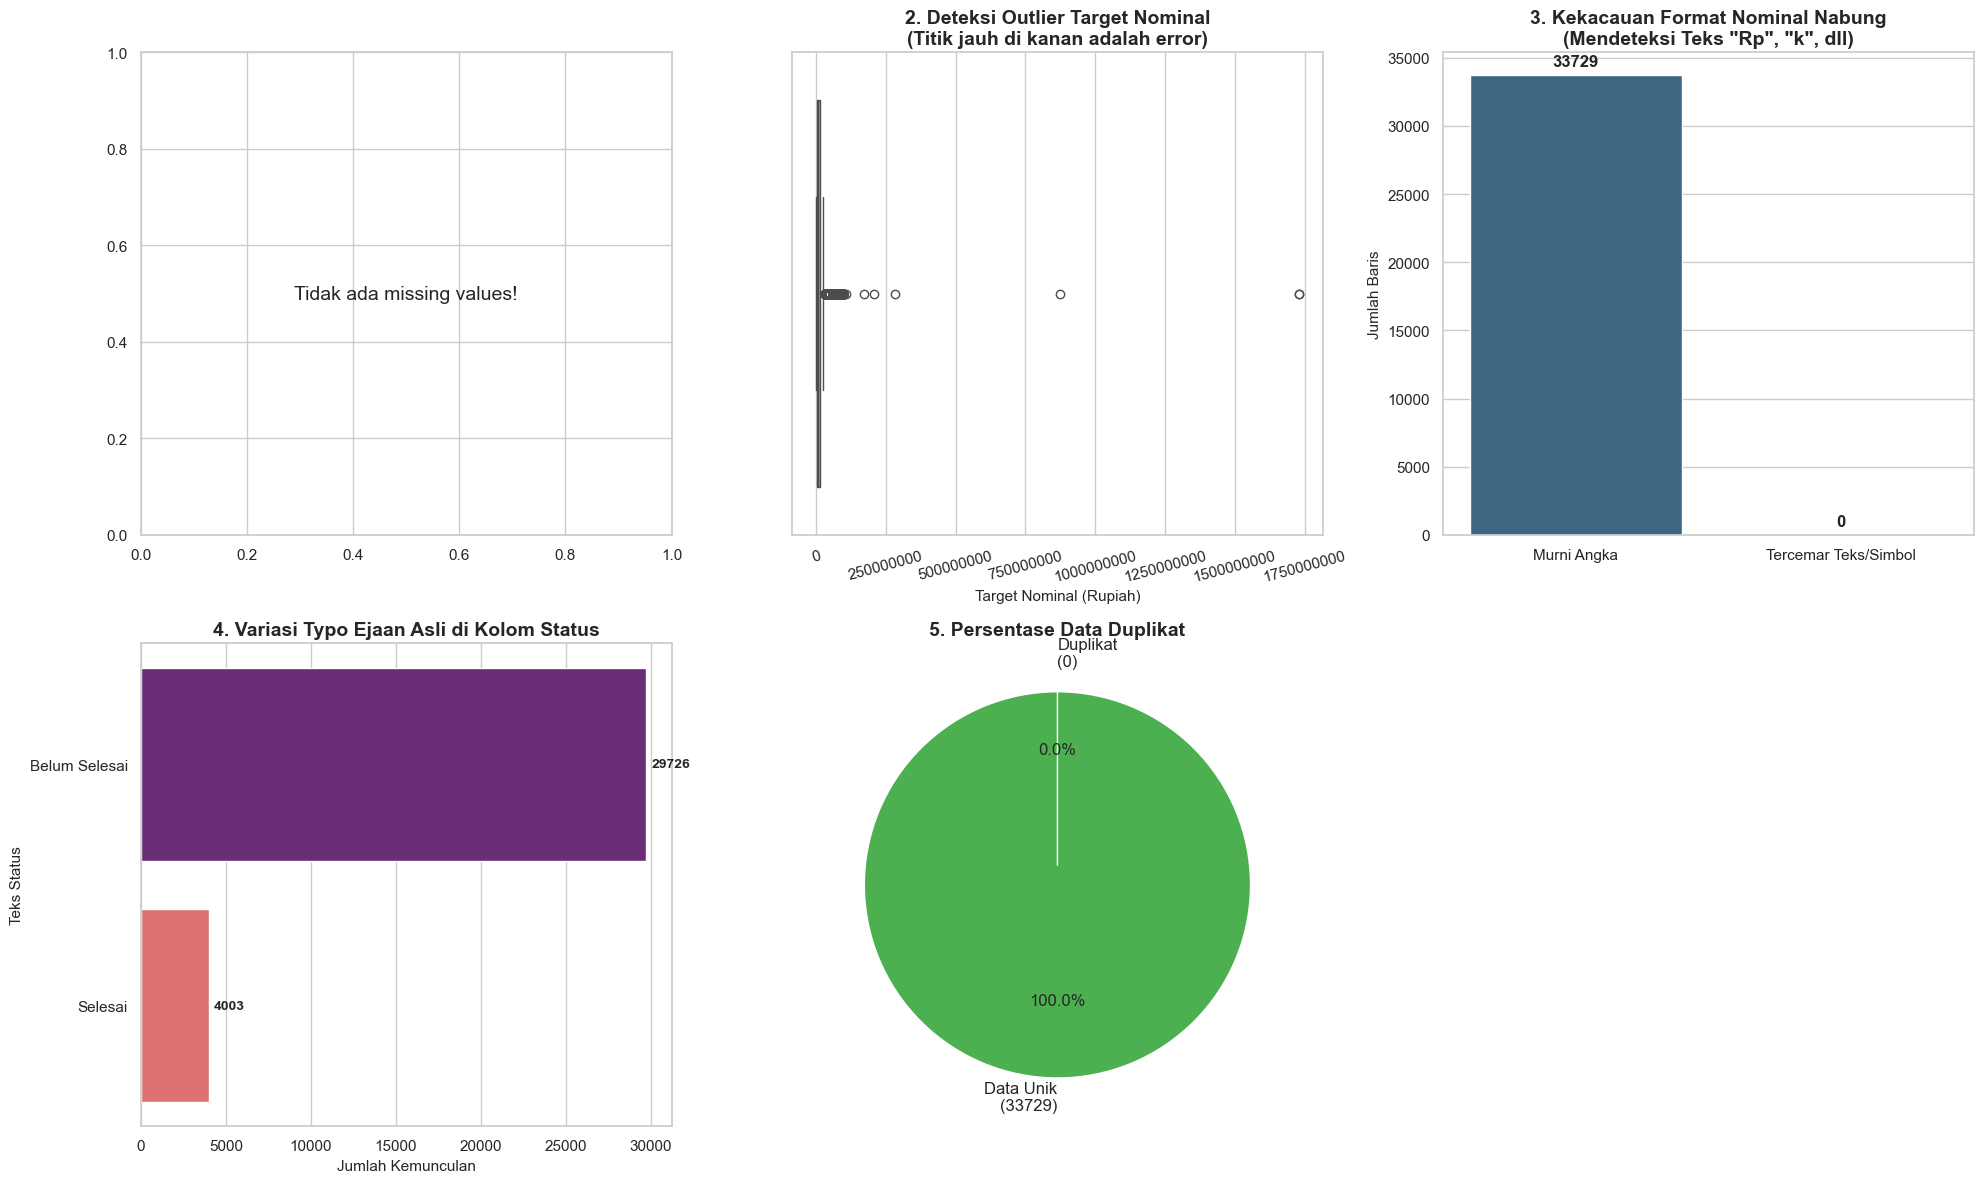

In [17]:
## Visualisasi Setelah Pembersihan Data
sns.set_theme(style="whitegrid")
# Perbesar ukuran canvas agar muat 5 grafik
plt.figure(figsize=(20, 12)) 

# GRAFIK 1: Jumlah Missing Values (Data Kosong)
plt.subplot(2, 3, 1) # (2 baris, 3 kolom, posisi 1)
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    sns.barplot(x=missing_data.values, y=missing_data.index, palette="Reds_r")
    plt.title('1. Jumlah Data Kosong (Missing Values)', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Baris Kosong', fontsize=11)
else:
    plt.text(0.5, 0.5, 'Tidak ada missing values!', ha='center', va='center', fontsize=14)

# GRAFIK 2: Deteksi Outlier (Target Nominal)
plt.subplot(2, 3, 2)
sns.boxplot(x=df['target_nominal'].dropna(), color='orange')
plt.title('2. Deteksi Outlier Target Nominal\n(Titik jauh di kanan adalah error)', fontsize=14, fontweight='bold')
plt.xlabel('Target Nominal (Rupiah)', fontsize=11)
plt.ticklabel_format(style='plain', axis='x')
plt.xticks(rotation=15)

# GRAFIK 3: Kekacauan Format Nominal Nabung
plt.subplot(2, 3, 3)
nominal_dropna = df['nominal_nabung'].dropna().astype(str)
murni_angka = nominal_dropna.str.isnumeric().sum()
mengandung_teks = len(nominal_dropna) - murni_angka

bars = sns.barplot(x=['Murni Angka', 'Tercemar Teks/Simbol'], y=[murni_angka, mengandung_teks], palette="viridis")
plt.title('3. Kekacauan Format Nominal Nabung\n(Mendeteksi Teks "Rp", "k", dll)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Baris', fontsize=11)

for i, v in enumerate([murni_angka, mengandung_teks]):
    bars.text(i, v + (max(murni_angka, mengandung_teks)*0.02), str(v), ha='center', fontsize=12, fontweight='bold')

# GRAFIK 4: Kekacauan Teks / Typo di Kolom Status
plt.subplot(2, 3, 4)

status_counts = df['status'].value_counts()

sns.barplot(x=status_counts.values, y=status_counts.index, palette="magma")
plt.title('4. Variasi Typo Ejaan Asli di Kolom Status', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Kemunculan', fontsize=11)
plt.ylabel('Teks Status', fontsize=11)

# Tambahkan label angka di sebelah kanan setiap batang
for i, v in enumerate(status_counts.values):
    plt.text(v + (max(status_counts.values)*0.01), i, str(v), va='center', fontsize=10, fontweight='bold')

# GRAFIK 5: Proporsi Duplikasi Data
plt.subplot(2, 3, 5)
total_rows = len(df)
duplicate_rows = df.duplicated().sum()
unique_rows = total_rows - duplicate_rows

plt.pie([unique_rows, duplicate_rows], 
        labels=[f'Data Unik\n({unique_rows})', f'Duplikat\n({duplicate_rows})'], 
        autopct='%1.1f%%', 
        colors=['#4CAF50', '#F44336'], 
        startangle=90, 
        explode=[0, 0.1], 
        textprops={'fontsize': 12})
plt.title('5. Persentase Data Duplikat', fontsize=14, fontweight='bold')

# Tampilkan semua grafik sekaligus dengan rapi
plt.tight_layout()
plt.show()

In [18]:
df.head(20)

,id_tabungan,counter_tabungan,tanggal_nabung,nama_goal,target_nominal,nominal_nabung,total_terkumpul,sisa_target,status,jarak_hari_nabung,persentase_terkumpul
0,TAB-0001,1,2021-06-12,Dana Darurat,9720000,1134942,1134942,8585058,Belum Selesai,0,11.68
1,TAB-0001,2,2021-06-26,Dana Darurat,9720000,948640,2083582,7636418,Belum Selesai,14,21.44
2,TAB-0001,3,2021-07-15,Dana Darurat,9720000,1056415,3139997,6580003,Belum Selesai,19,32.30
3,TAB-0001,4,2021-07-22,Dana Darurat,9720000,1036500,4176497,5543503,Belum Selesai,7,42.97
4,TAB-0001,5,2021-08-08,Dana Darurat,9720000,958707,5135204,4584796,Belum Selesai,17,52.83
5,TAB-0001,6,2021-08-24,Dana Darurat,9720000,906476,6041680,3678320,Belum Selesai,16,62.16
6,TAB-0001,9,2021-11-06,Dana Darurat,9720000,928793,8783571,936429,Belum Selesai,74,90.37
7,TAB-0001,10,2021-12-04,Dana Darurat,9720000,936429,9720000,0,Selesai,28,100.00
8,TAB-0002,1,2021-04-12,Beli Ipad/Tablet Nugas,6240000,220329,220329,6019671,Belum Selesai,0,3.53
9,TAB-0002,2,2021-05-12,Beli Ipad/Tablet Nugas,6240000,178688,399017,5840983,Belum Selesai,30,6.39
